# **Flood Impact Analysis: Kanawha River with Sage**                                                                                                                     
  ### A Natural Language Science Notebook                                                                                                           
  This notebook demonstrates **Sage** (Science Agent) — a natural language infrastructure for scientific data exploration on the [National Data Platform (NDP)](https://nationaldataplatform.org),  developed as part of the WENOKN project. Every step is expressed as a plain English prompt using the `%%ask` magic command, and results are returned in natural language with interactive maps and data visualizations.  
  
  **What this notebook does:**                                                                                                                                            
  1. Visualizes flood depth along the Kanawha River at 400,000 cfs using USACE HEC-RAS 2D model results                                                                   
  2. Identifies schools impacted by flooding, classified by severity (nuisance, minor, moderate, severe)                                                                  
  3. Finds flooded commercial buildings with structure value over $1 million, with visualizations
  4. Estimates the number of elderly residents (age 65+) at risk from the flood, with visualizations


####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [ ]:
# Use GLM-5 from National Research Platform
LLM = {
    "model": "glm-5",
    "url": "https://ellm.nrp-nautilus.io/v1",
    "api_key_env": "NRP_API_KEY",
}

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }


#### **Install Argus from GitHub Repo**

In [ ]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded NRP_API_KEY from Colab Secrets
  ✓ ARGUS dependencies already installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/hydrography/kanawha-flood-depth
https://github.com/klinucsd/sage_skills/tree/main/hydrography/kanawha-reach-impact
https://github.com/klinucsd/sage_skills/tree/main/hydrography/kanawha-cikr-impact
https://github.com/klinucsd/sage_skills/tree/main/hydrography/kanawha-nsi-impact

In [ ]:
%%ask
Show the flood depth for the Kanawha River at 400,000 cfs

400,000 cfs is an exact scenario match. Creating the WMS layer file.

The WMS layer file already exists with the correct configuration. No changes needed.

The map shows the USACE HEC-RAS flood depth raster for the Kanawha River at **400,000 cfs** . Depth values (in feet above ground) are rendered by GeoServer directly from the `Depth_400000_5070` layer. Darker shades indicate greater water depth.

In [ ]:
%%ask
Show me all schools impacted by the Kanawha River flood at 400,000 cfs

Now I'll run the CIKR impact script for schools at 400,000 cfs.

Now running the script to fetch schools and sample flood depths at 400,000 cfs.

The analysis is complete. Here are the results:

---

## School Flood Impact at 400,000 cfs — Kanawha River

| Metric | Count |
|--------|-------|
| **Total schools in study area** | 111 |
| **Schools flooded (any severity)** | **62** |
| Schools not flooded | 49 |

### Breakdown by Severity

| Severity | Schools |
|----------|---------|
| **Severe (>6 ft)** | **48** |
| **Moderate (3–6 ft)** | **7** |
| **Nuisance (0–1 ft)** | **5** |
| **Minor (1–3 ft)** | **2** |

The vast majority of flooded schools (48 of 62) fall into the **Severe** category with flood depths exceeding 6 feet. Some locations show extremely deep flooding — the hardest-hit school sits at nearly **84 ft** of water, and several others exceed 40–50 ft, indicating they are deep within the floodplain.

**Data sources** : USACE HEC-RAS 2D depth raster (400k cfs scenario), CIKR facility points from GeoServer WFS. Depth values are feet above ground surface.

Now I'll write and run the script to query NSI data and filter for flooded commercial buildings with structure value over &#36;1M.

Data is ready — 1,884 flooded commercial buildings with structure value > &#36;1M. Now generating the visualizations.

Now let me verify the WMS layer exists from the earlier cell so I can include it on the map.

## Flooded Commercial Buildings — Kanawha River at 400,000 cfs

At **400,000 cfs** , **1,884 commercial buildings** with a structure value exceeding **&#36;1 million** are flooded along the Kanawha River. These buildings represent a combined **&#36;6.4 billion** in structure value and employ over **57,200 people** .

### Severity Breakdown

| Severity | Buildings | Structure Value | Avg Depth |
|----------|-----------|----------------|-----------|
| **Severe (>6 ft)** | 1,636 | &#36;5,752.6M | 17.6 ft |
| **Moderate (3–6 ft)** | 129 | &#36;375.8M | 4.6 ft |
| **Minor (1–3 ft)** | 87 | &#36;192.2M | 1.8 ft |
| **Nuisance (0–1 ft)** | 32 | &#36;74.7M | 0.6 ft |

An overwhelming **87%** of these high-value commercial buildings face severe flooding (>6 ft), accounting for **&#36;5.75 billion** in structure value alone.

### By Building Type

| Building Type | Count | Structure Value | Avg Depth |
|---------------|-------|----------------|-----------|
| Professional/Technical | 365 | &#36;1,437M | 14.3 ft |
| Retail | 386 | &#36;984M | 17.1 ft |
| Wholesale | 232 | &#36;785M | 15.6 ft |
| Personal/Repair Services | 219 | &#36;461M | 17.4 ft |
| Entertainment/Recreation | 212 | &#36;537M | 14.7 ft |
| Medical Office | 156 | &#36;491M | 13.1 ft |
| Bank | 96 | &#36;274M | 16.6 ft |
| Hotel/Motel (RES4) | 59 | &#36;292M | 19.4 ft |
| Garage | 51 | &#36;276M | 15.5 ft |
| Agriculture | 46 | &#36;62M | 19.5 ft |
| Hospital (COM6) | 35 | &#36;662M | 13.1 ft |
| Nursing Home (RES6) | 17 | &#36;76M | 13.5 ft |
| Dormitory (RES5) | 8 | &#36;54M | 7.4 ft |
| Theater | 2 | &#36;4M | 8.1 ft |

### Total Economic Exposure

| Category | Value |
|----------|-------|
| **Structure Value** | &#36;6,395.3M |
| **Contents Value** | &#36;6,623.1M |
| **Vehicle Value** | &#36;666.2M |
| **Total Exposure** | **&#36;13,684.6M** |
| **Employees at Risk** | 57,200 |

### Map

### Visualizations


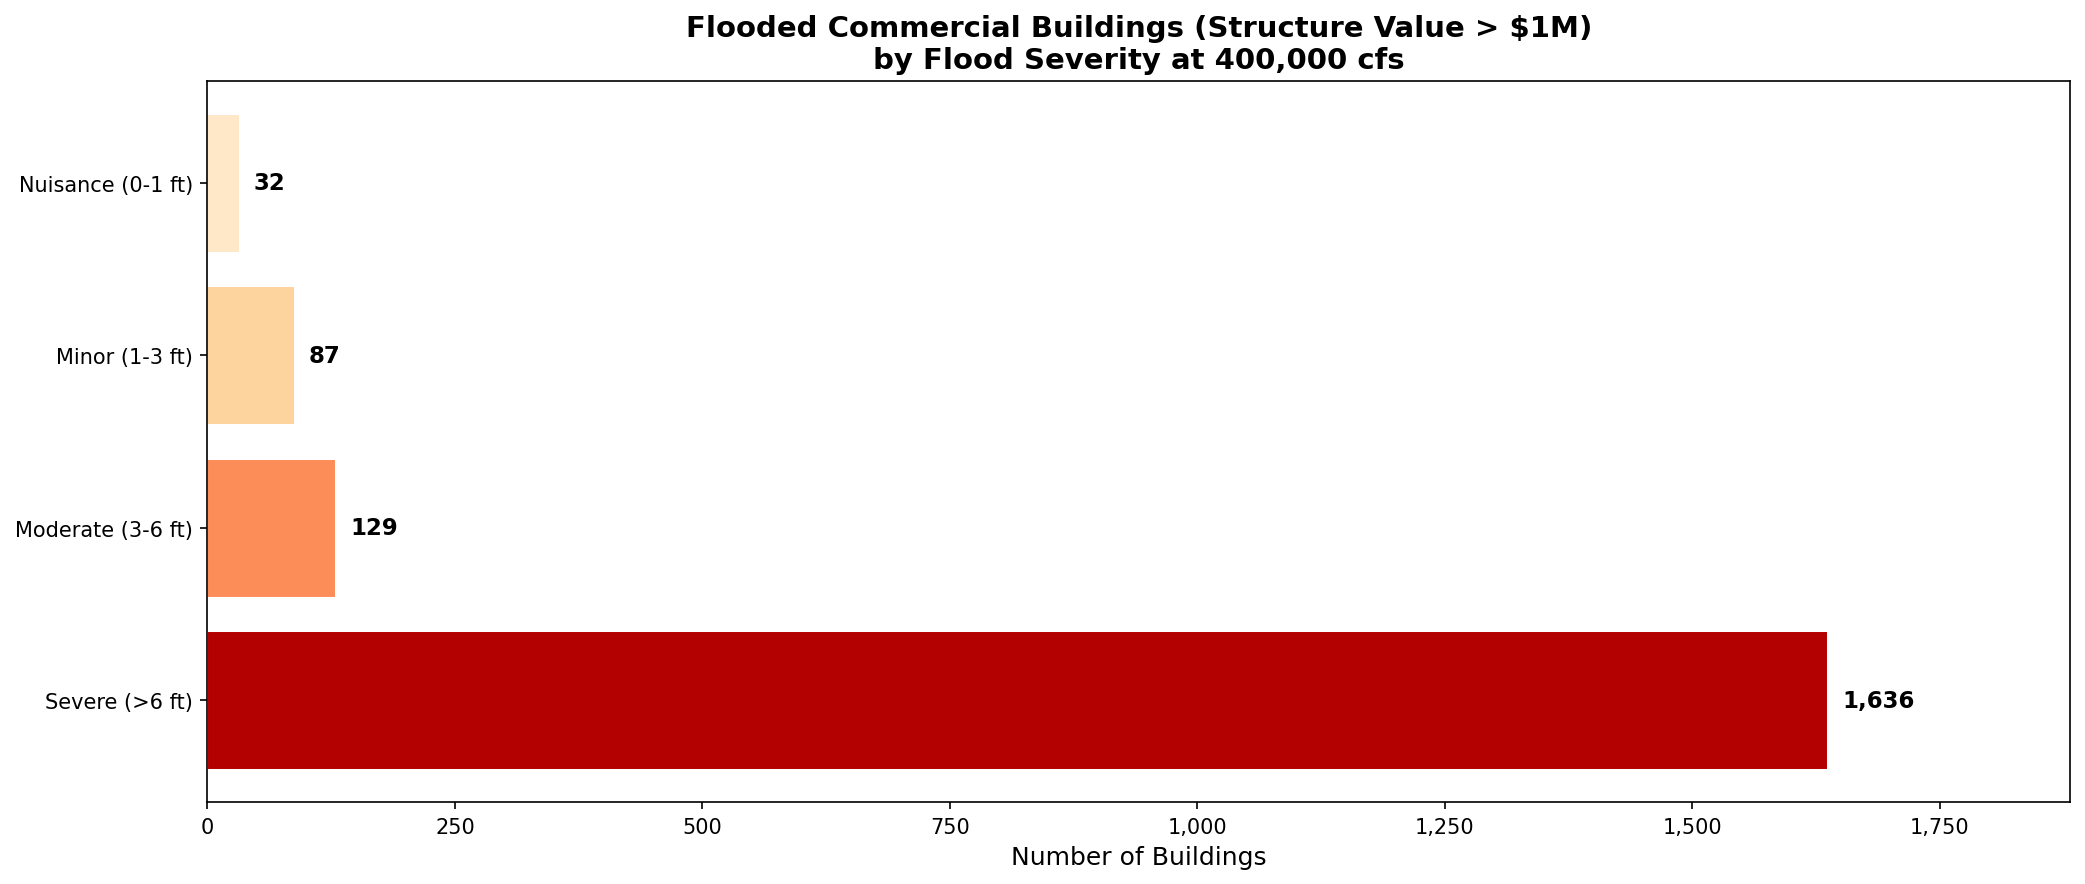


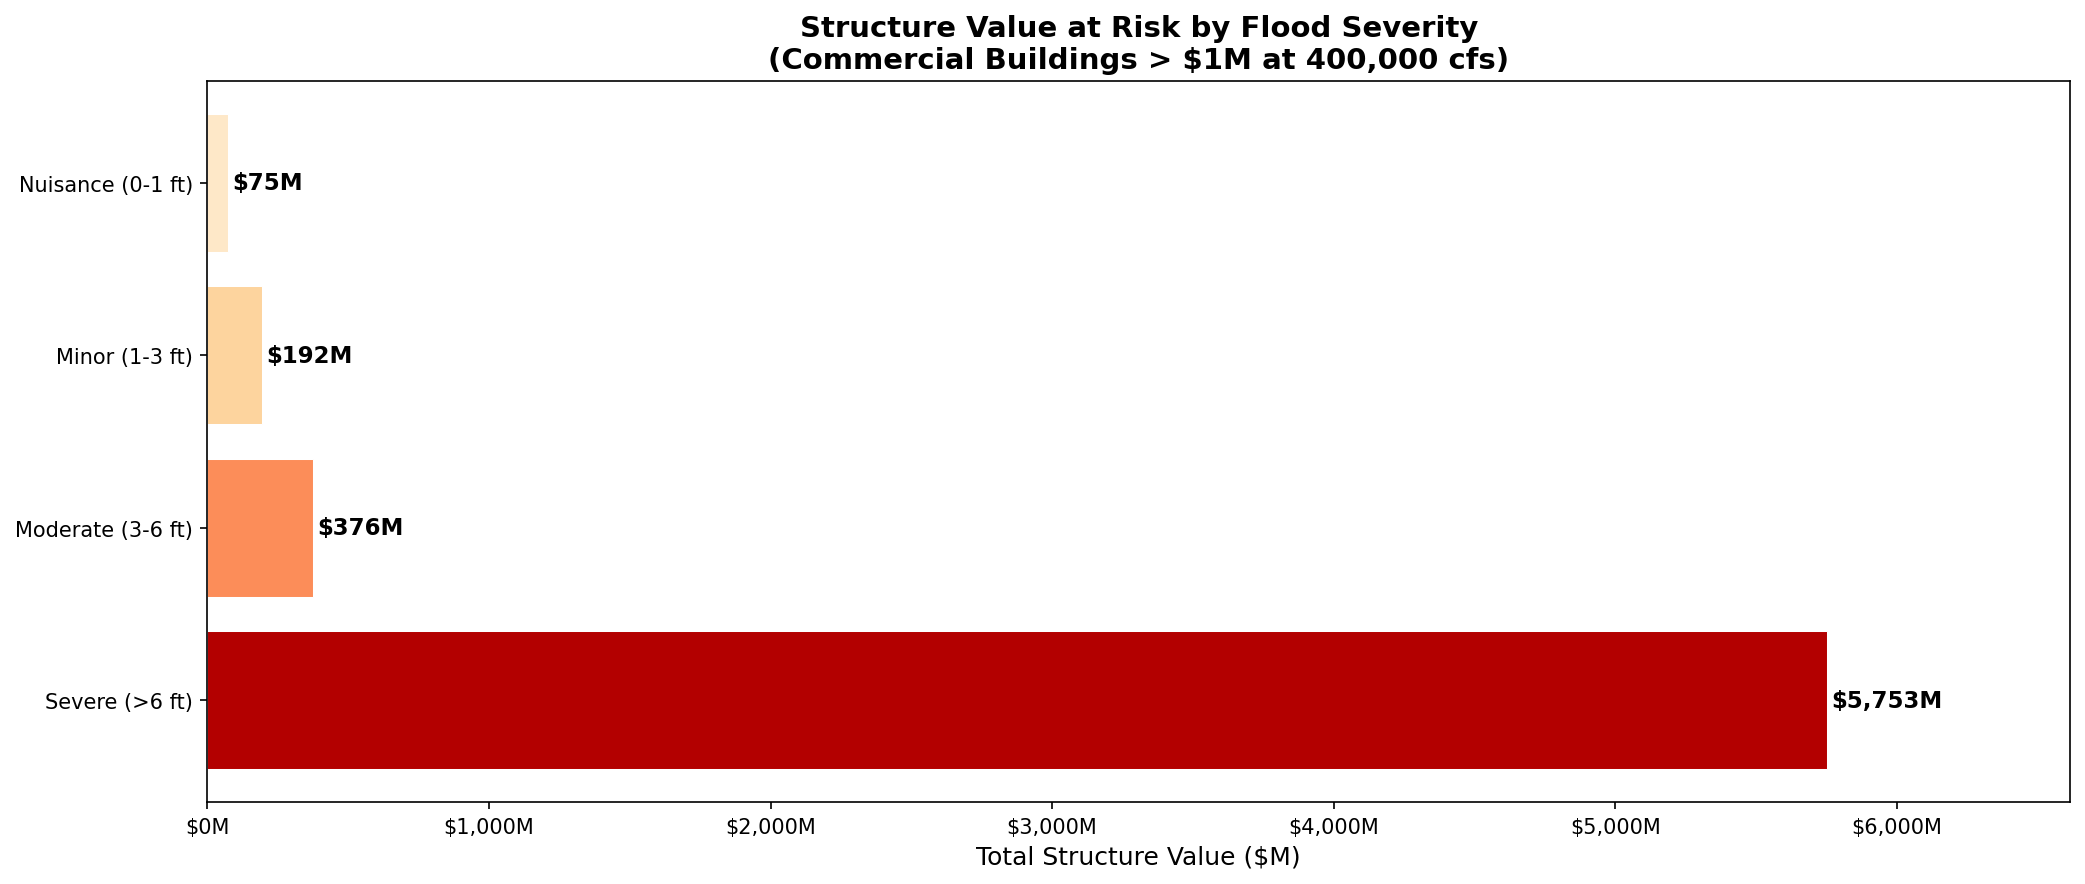


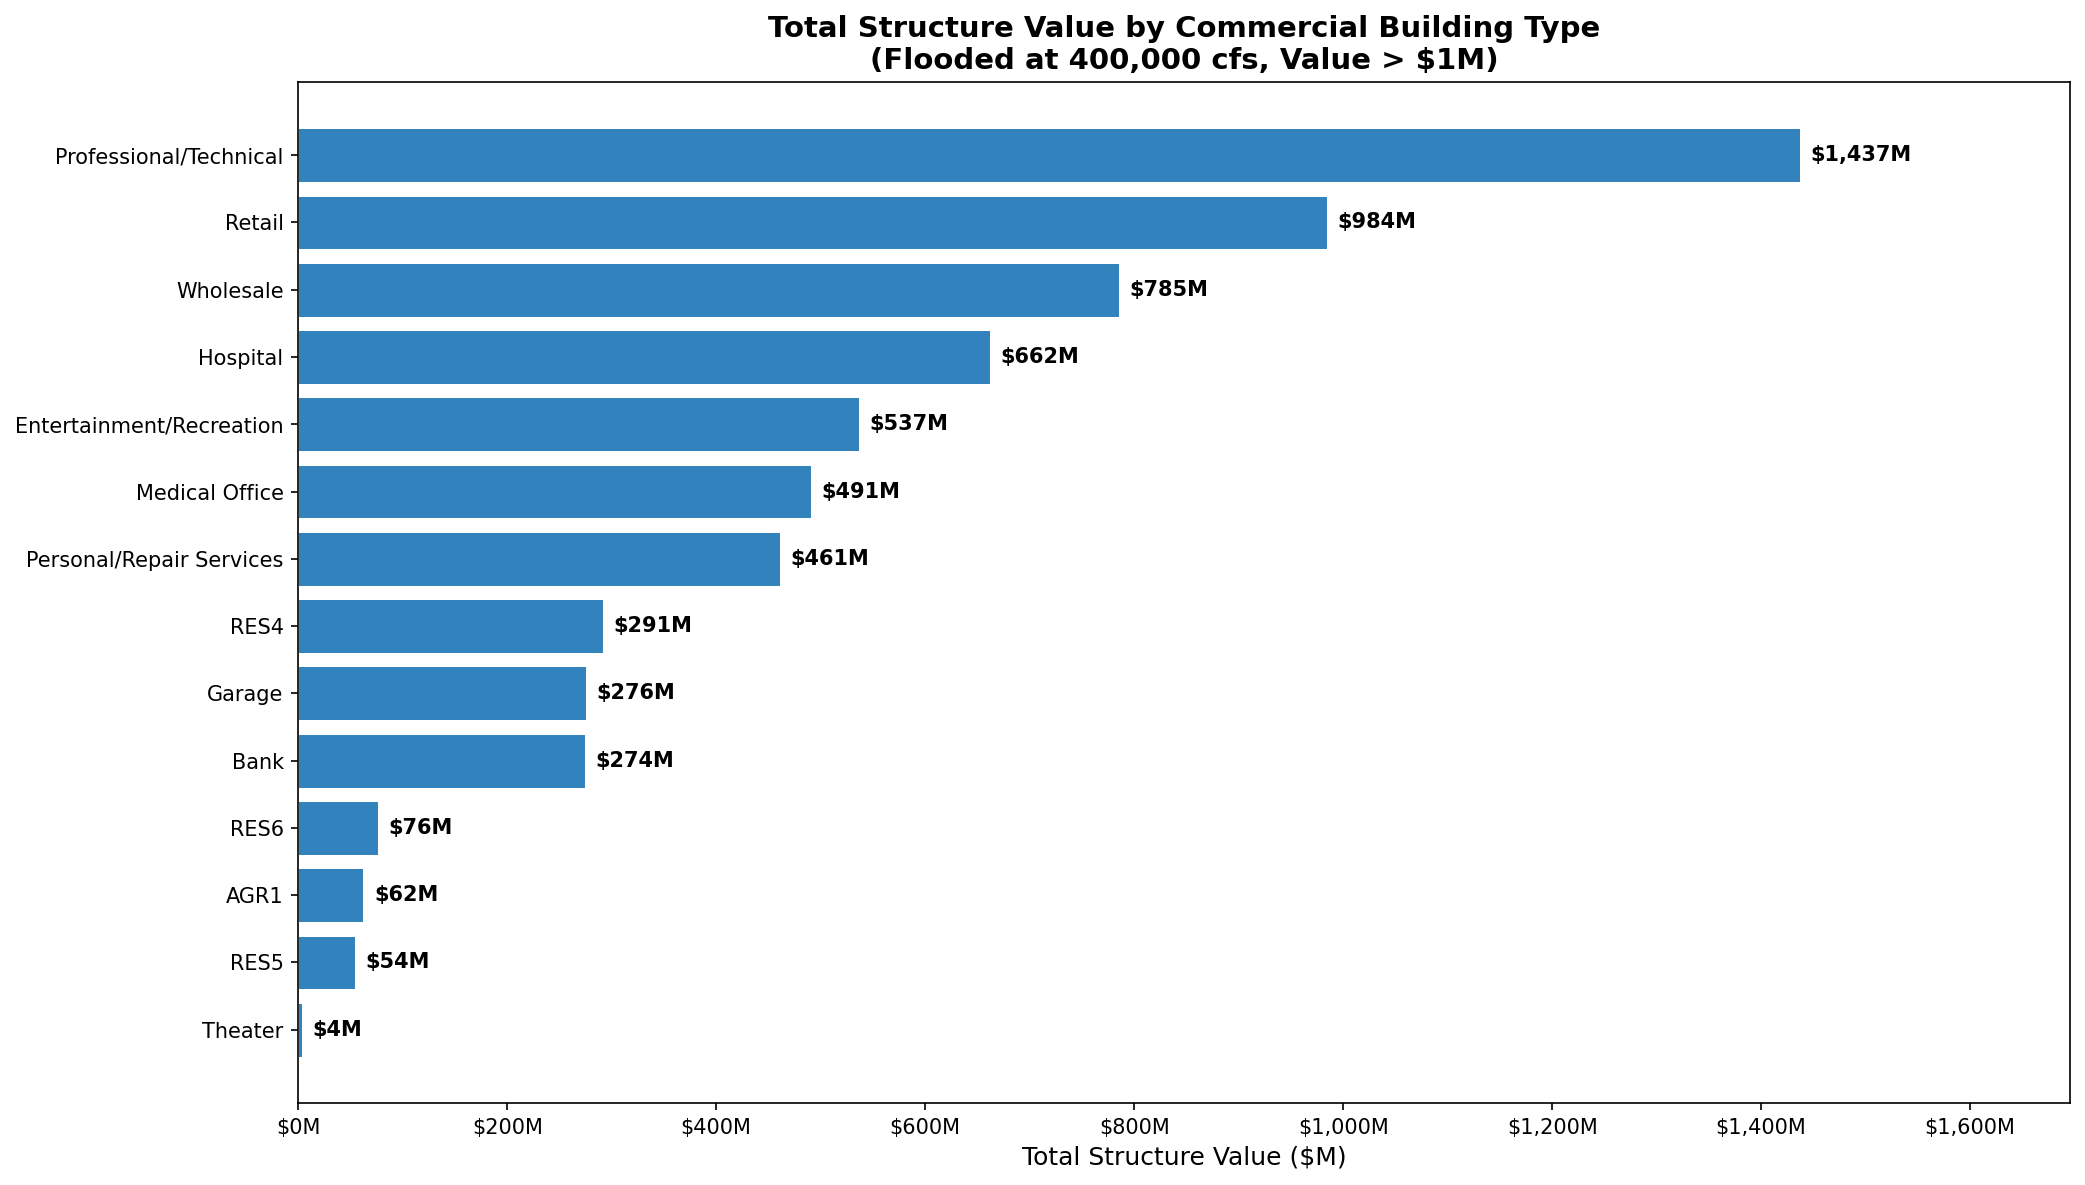


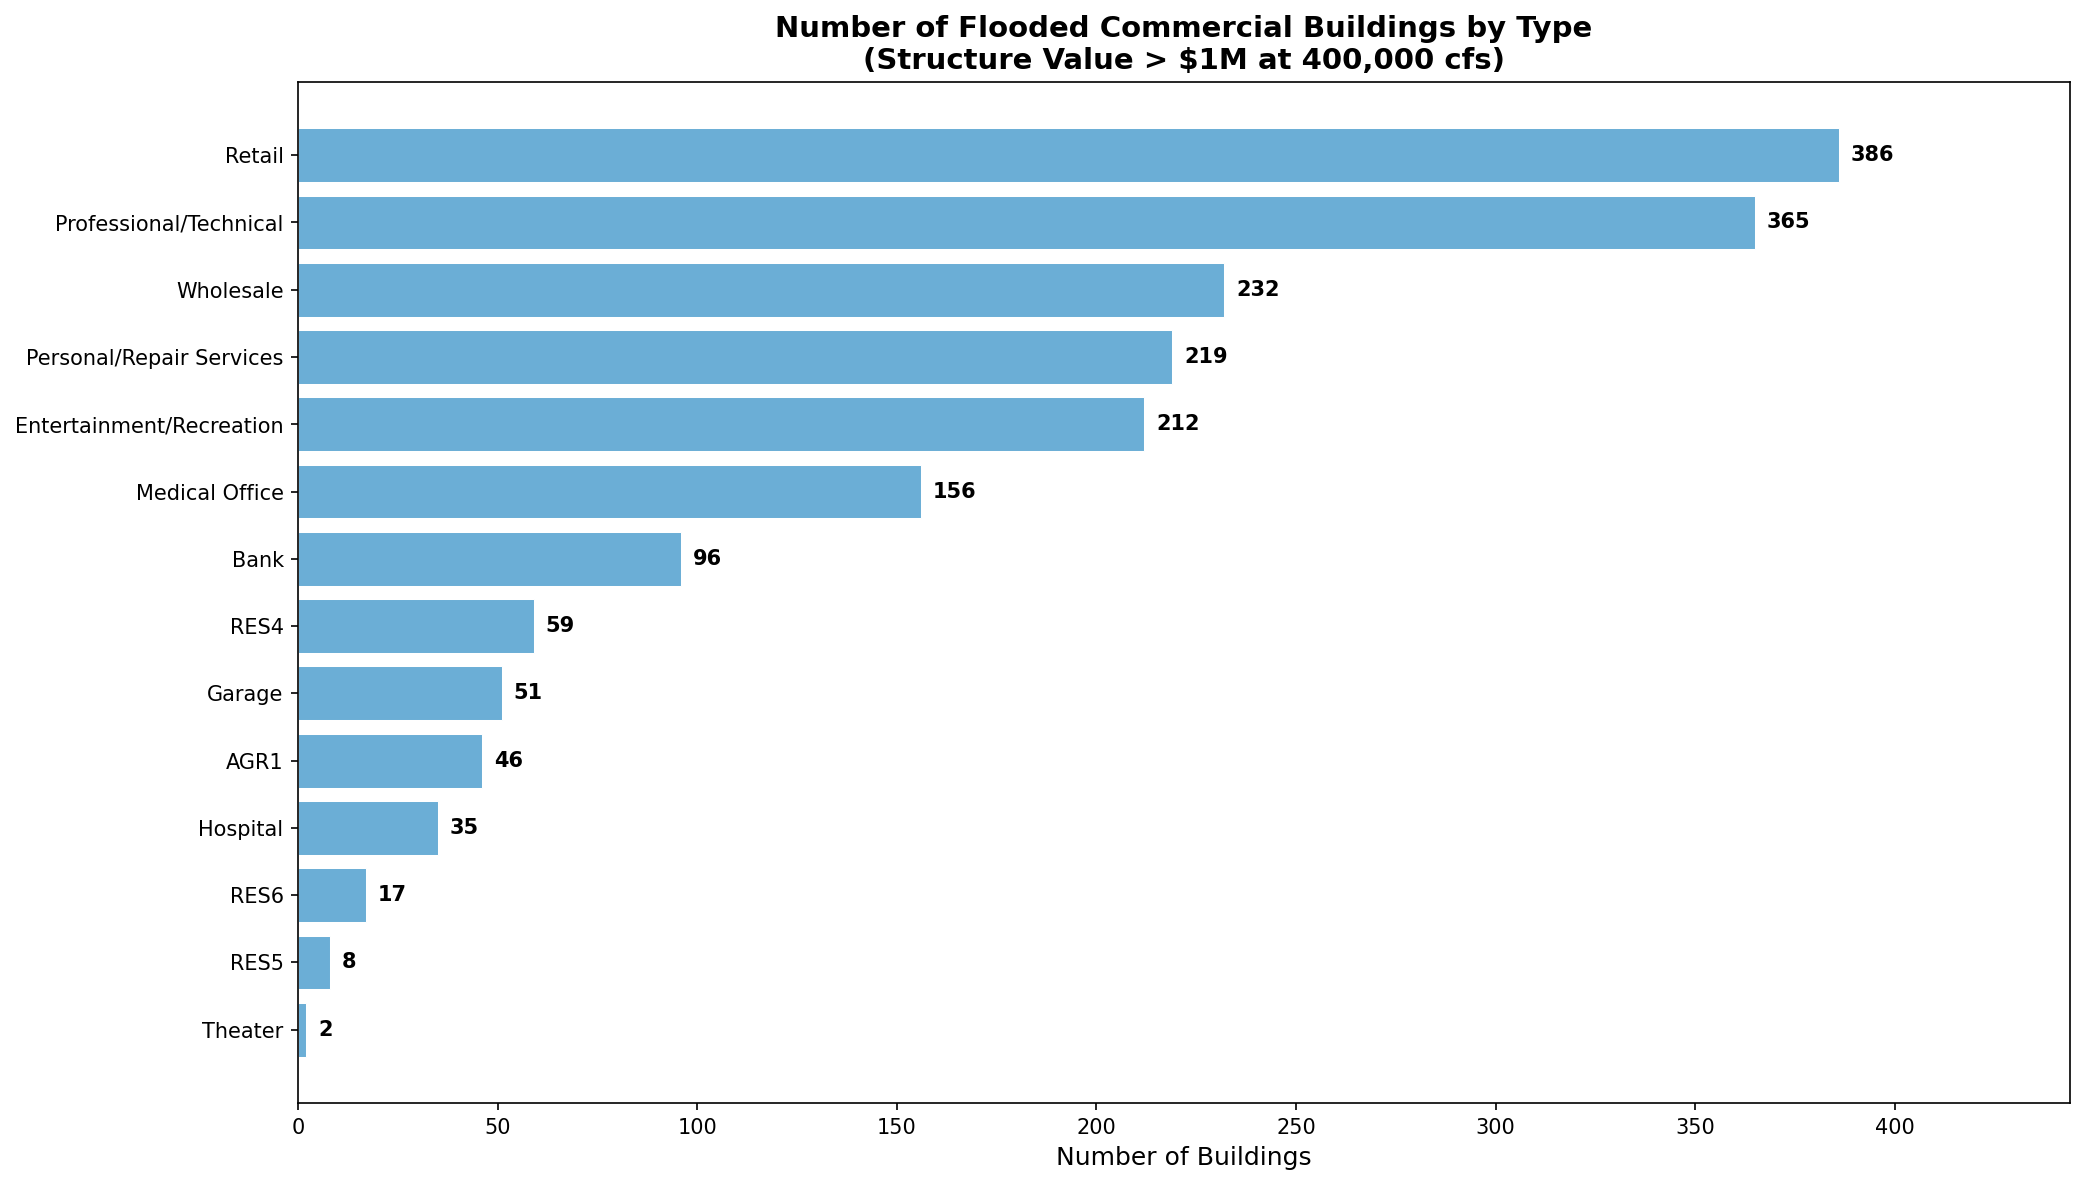


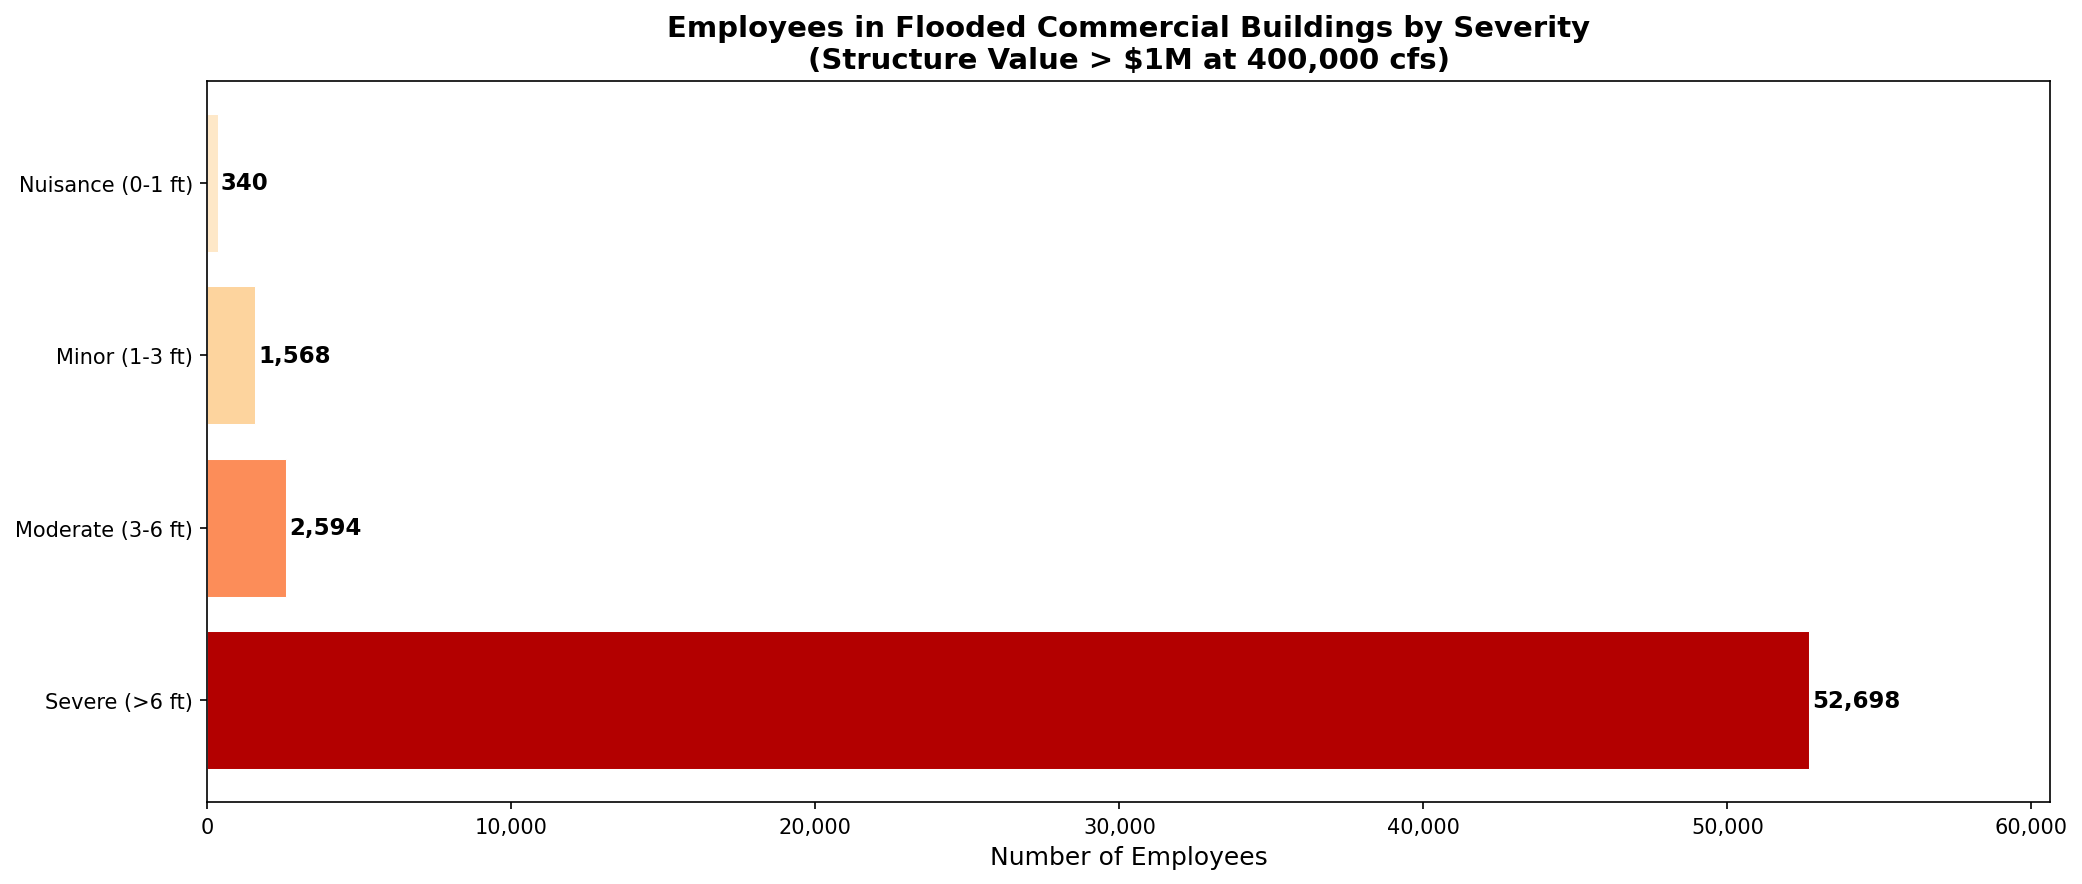


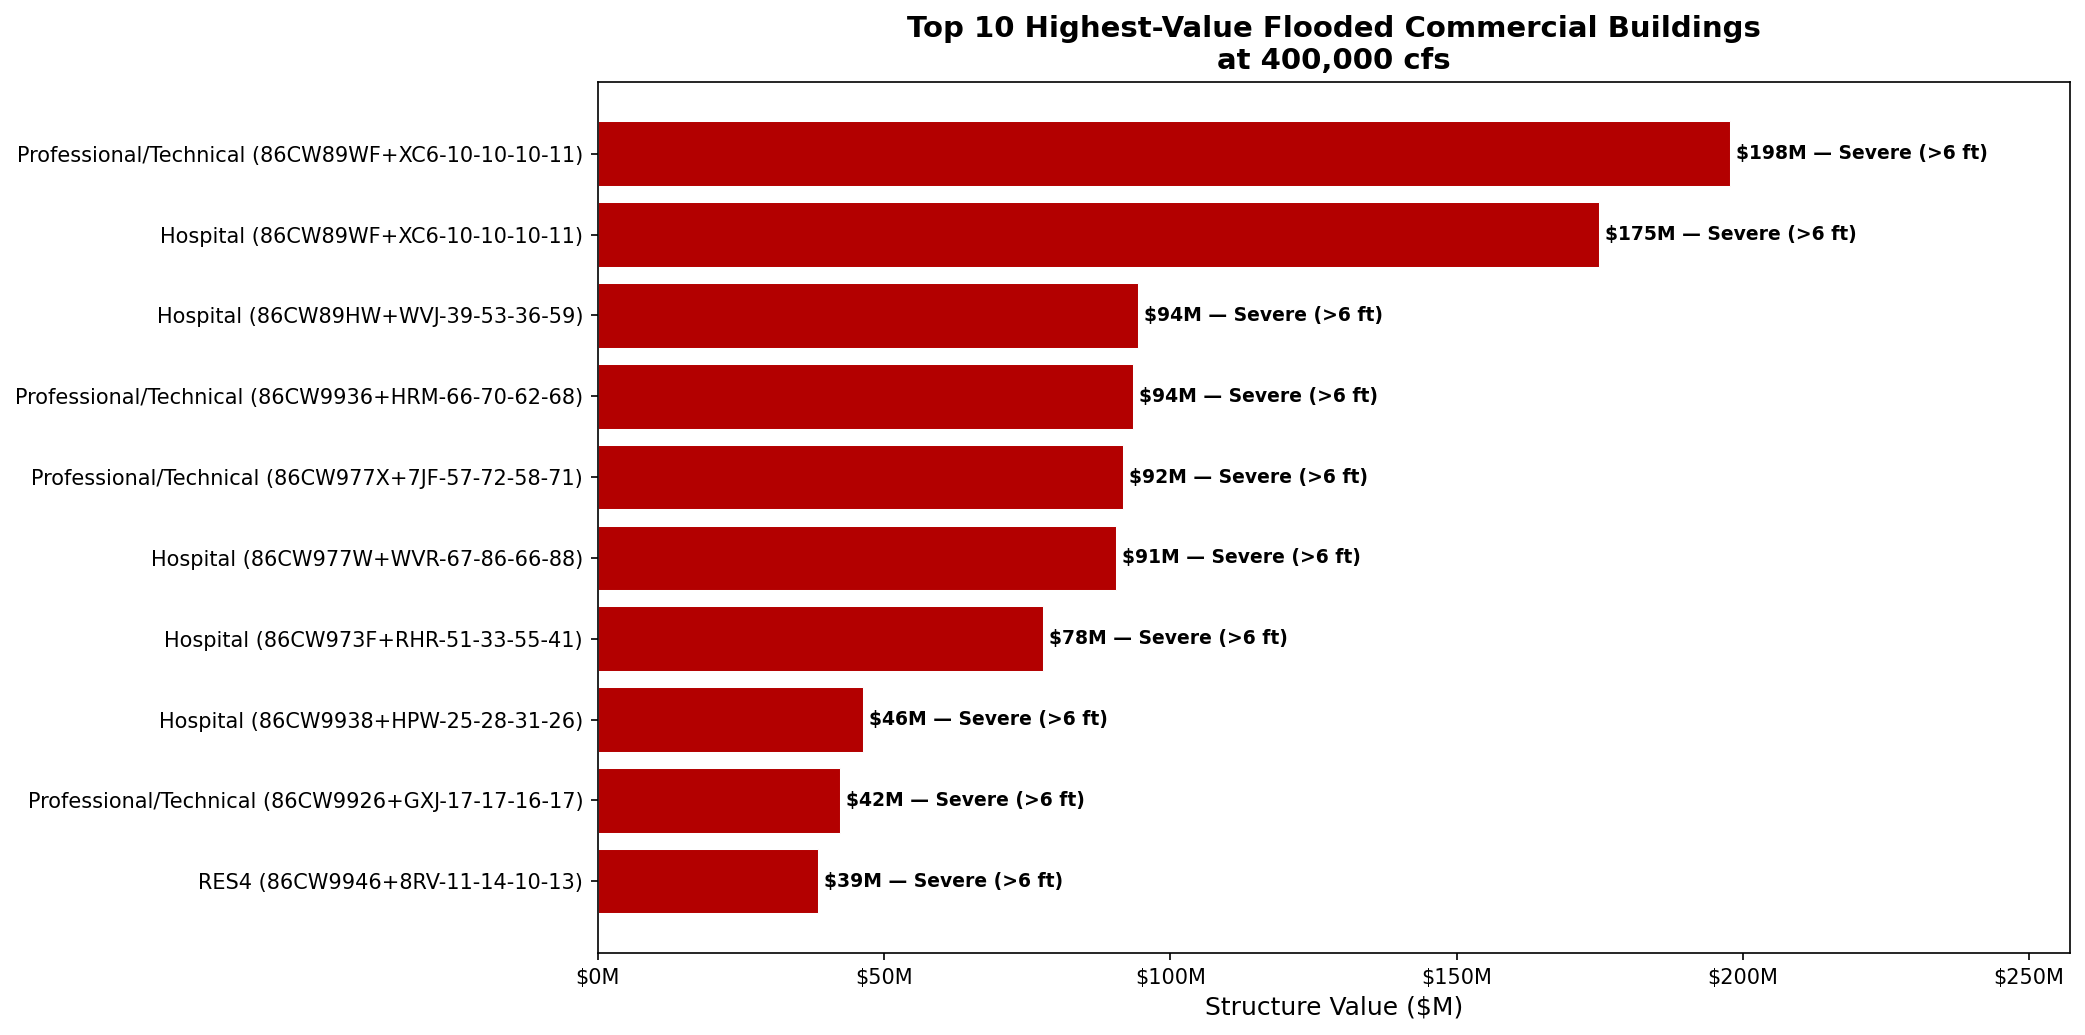

The analysis is complete. Key takeaway: at 400,000 cfs, the Kanawha River flood puts **&#36;13.7 billion** in total economic exposure at risk across 1,884 high-value commercial buildings, with nearly 90% facing severe flooding depths exceeding 6 feet. Professional/Technical services and Retail buildings are the most impacted both in count and dollar value.

In [ ]:
%%ask
Find all flooded commercial buildings along the Kanawha River with structure value
over $1 million at 400,000 cfs. Please generate visualizations of the result

Now I'll write the analysis script that fetches NSI data, samples flood depths at 400k cfs, filters for commercial buildings with structure value > &#36;1M, and generates the map and visualizations.

Running the analysis script now.

The analysis completed successfully. Let me update the todos and prepare the final report.

## Flooded Commercial Buildings with Structure Value > &#36;1M — Kanawha River at 400,000 cfs

At **400,000 cfs** , **1,884 commercial buildings** with structure values exceeding &#36;1 million are flooded along the Kanawha River, representing **&#36;13.68 billion** in total economic exposure (structure + contents + vehicles) and impacting an estimated **57,200 employees** .

### Overall Summary

| Metric | Value |
|--------|-------|
| **Flooded high-value commercial buildings** | 1,884 |
| **Total structure value at risk** | &#36;6.40B |
| **Total contents value at risk** | &#36;6.62B |
| **Total vehicle value at risk** | &#36;666.2M |
| **Total economic exposure** | &#36;13.68B |
| **Employees impacted** | 57,200 |
| **Median flood depth** | 12.7 ft |
| **Mean flood depth** | 15.7 ft |

### Severity Breakdown

| Severity | Buildings | Structure Value |
|----------|-----------|-----------------|
| **Severe (>6 ft)** | 1,636 (86.8%) | &#36;5.75B |
| **Moderate (3–6 ft)** | 129 (6.8%) | &#36;375.8M |
| **Minor (1–3 ft)** | 87 (4.6%) | &#36;192.2M |
| **Nuisance (0–1 ft)** | 32 (1.7%) | &#36;74.7M |

An overwhelming **86.8%** of these high-value commercial buildings face severe flooding exceeding 6 feet.

### Top Occupancy Types by Total Value

| Type | Buildings | Total Value | Mean Depth |
|------|-----------|-------------|------------|
| Professional/Technical Services | 365 | &#36;2.87B | 14.3 ft |
| Retail | 386 | &#36;1.97B | 17.1 ft |
| Hospital | 35 | &#36;1.66B | 13.1 ft |
| Wholesale | 232 | &#36;1.57B | 15.6 ft |
| Medical Office | 156 | &#36;1.23B | 13.1 ft |
| Entertainment/Recreation | 212 | &#36;1.07B | 14.7 ft |
| Personal/Repair Services | 219 | &#36;922.2M | 17.4 ft |
| Bank | 96 | &#36;548.0M | 16.6 ft |


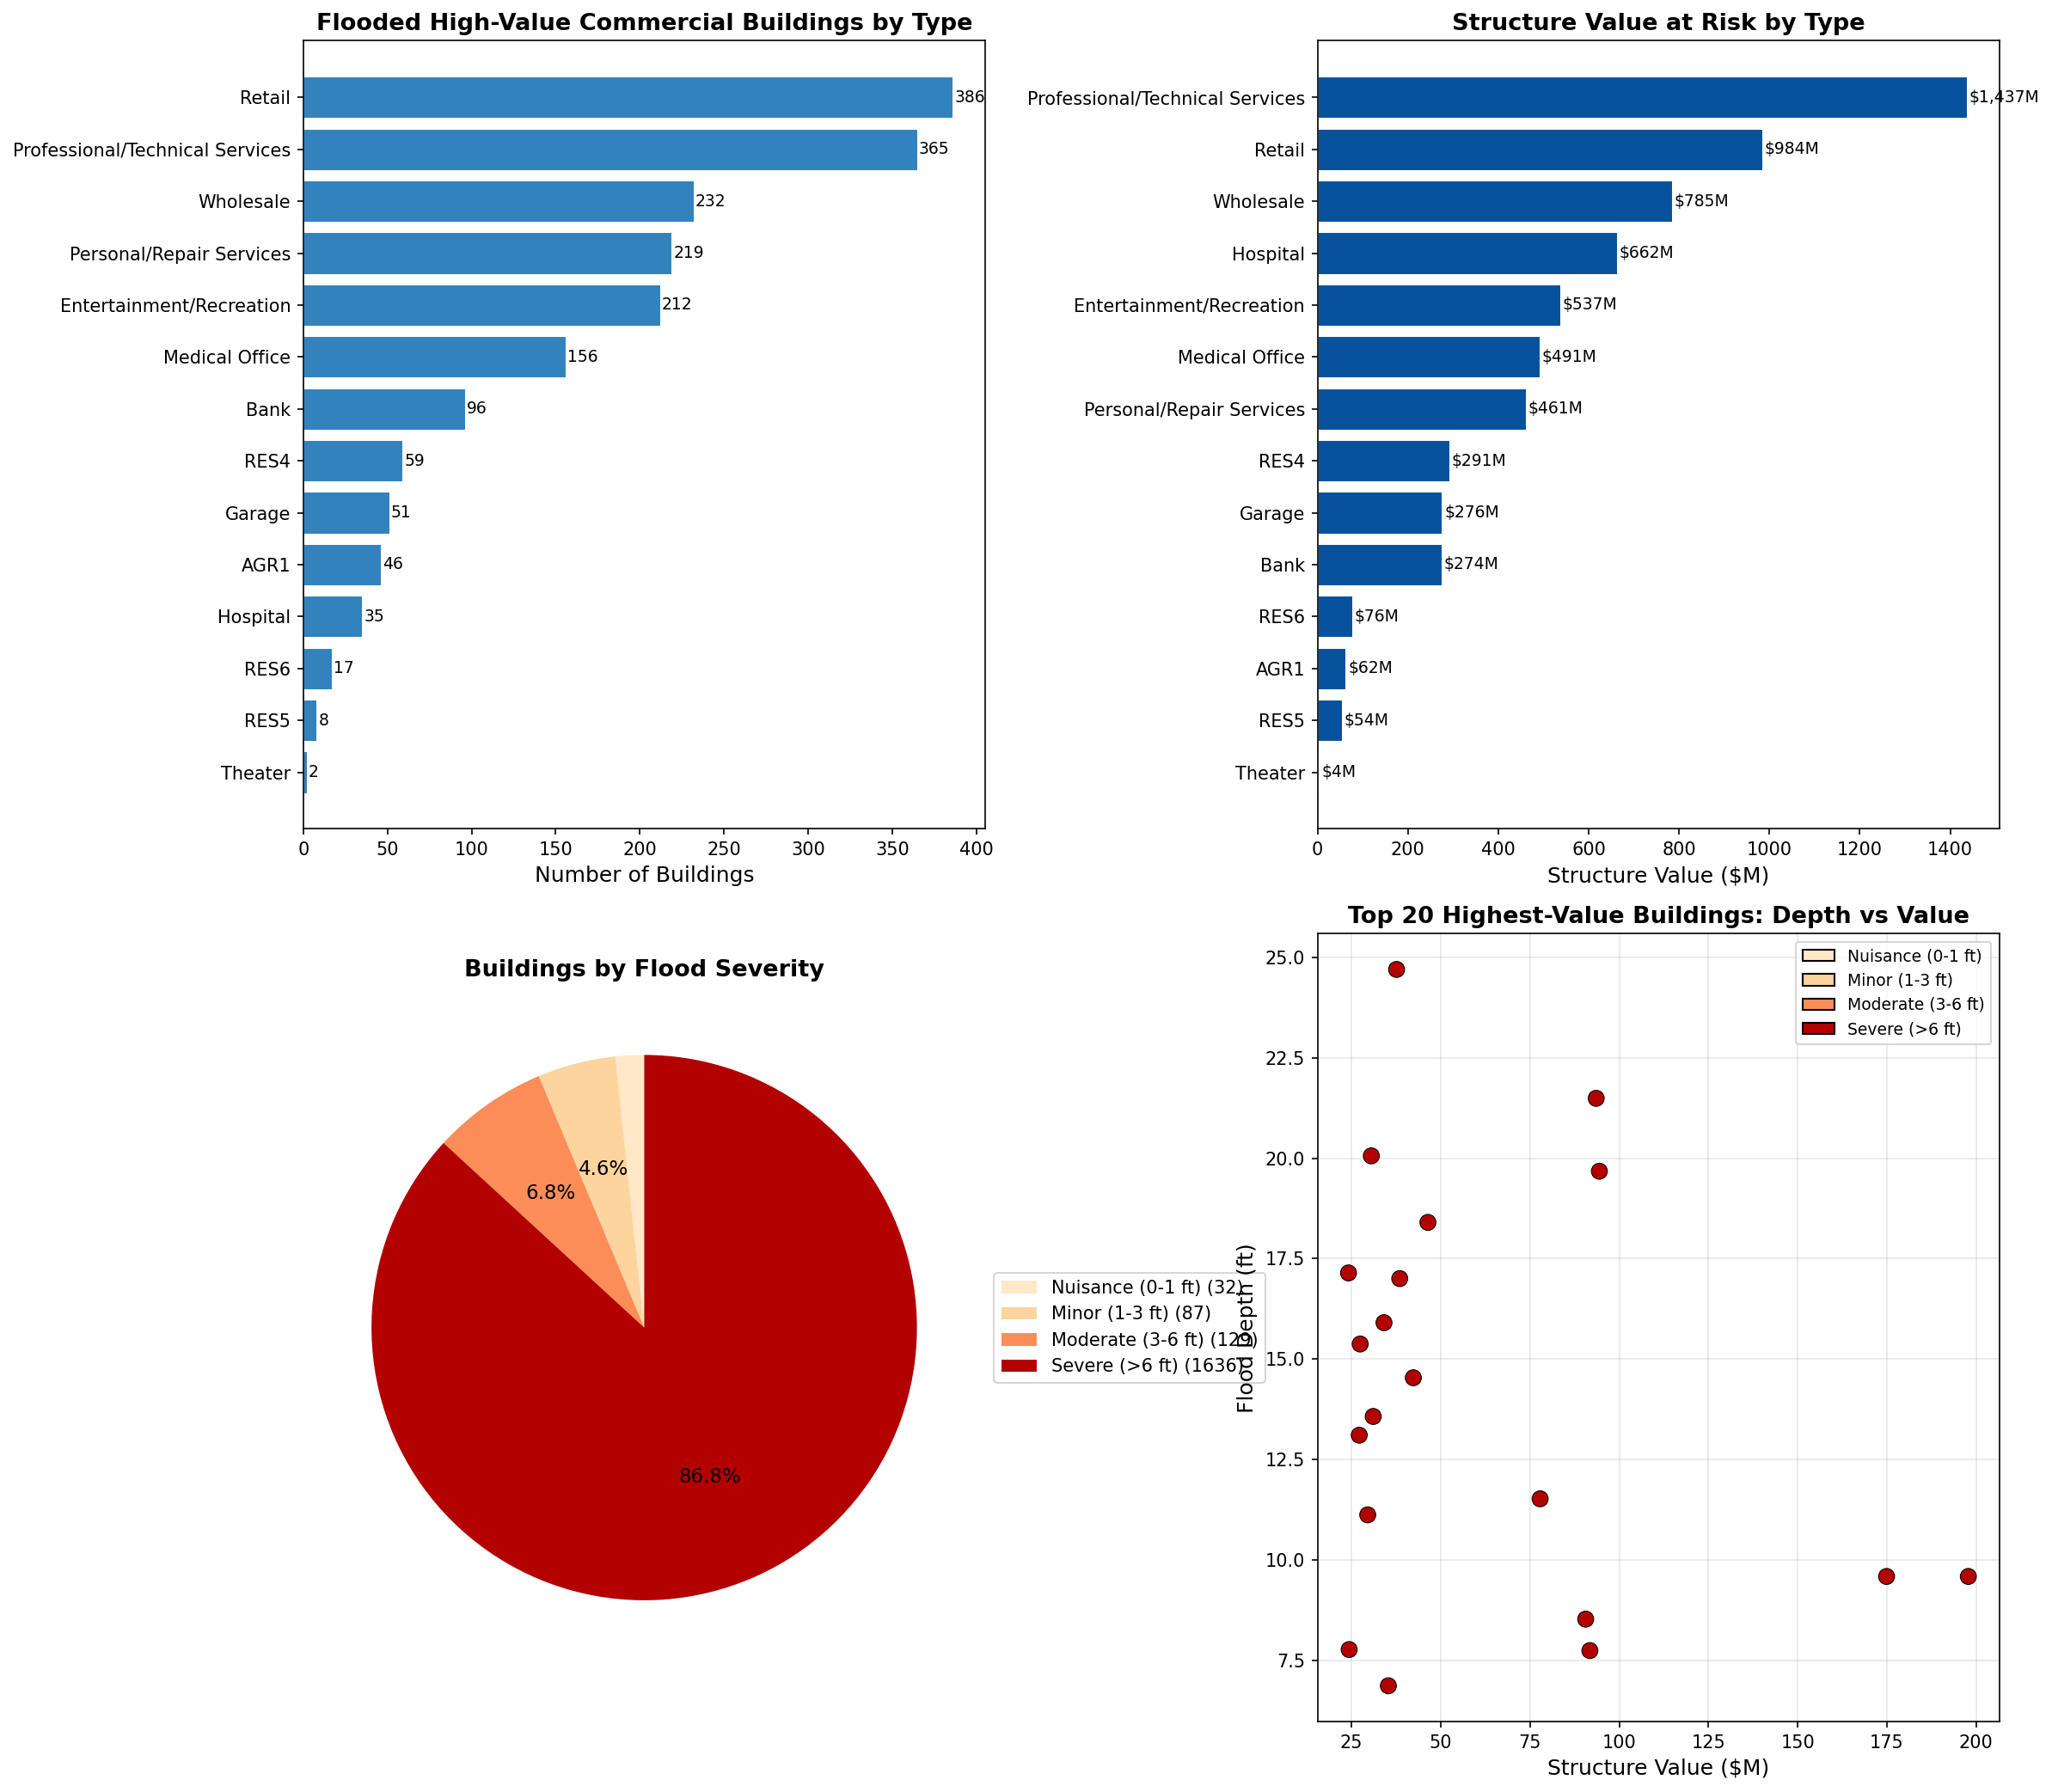


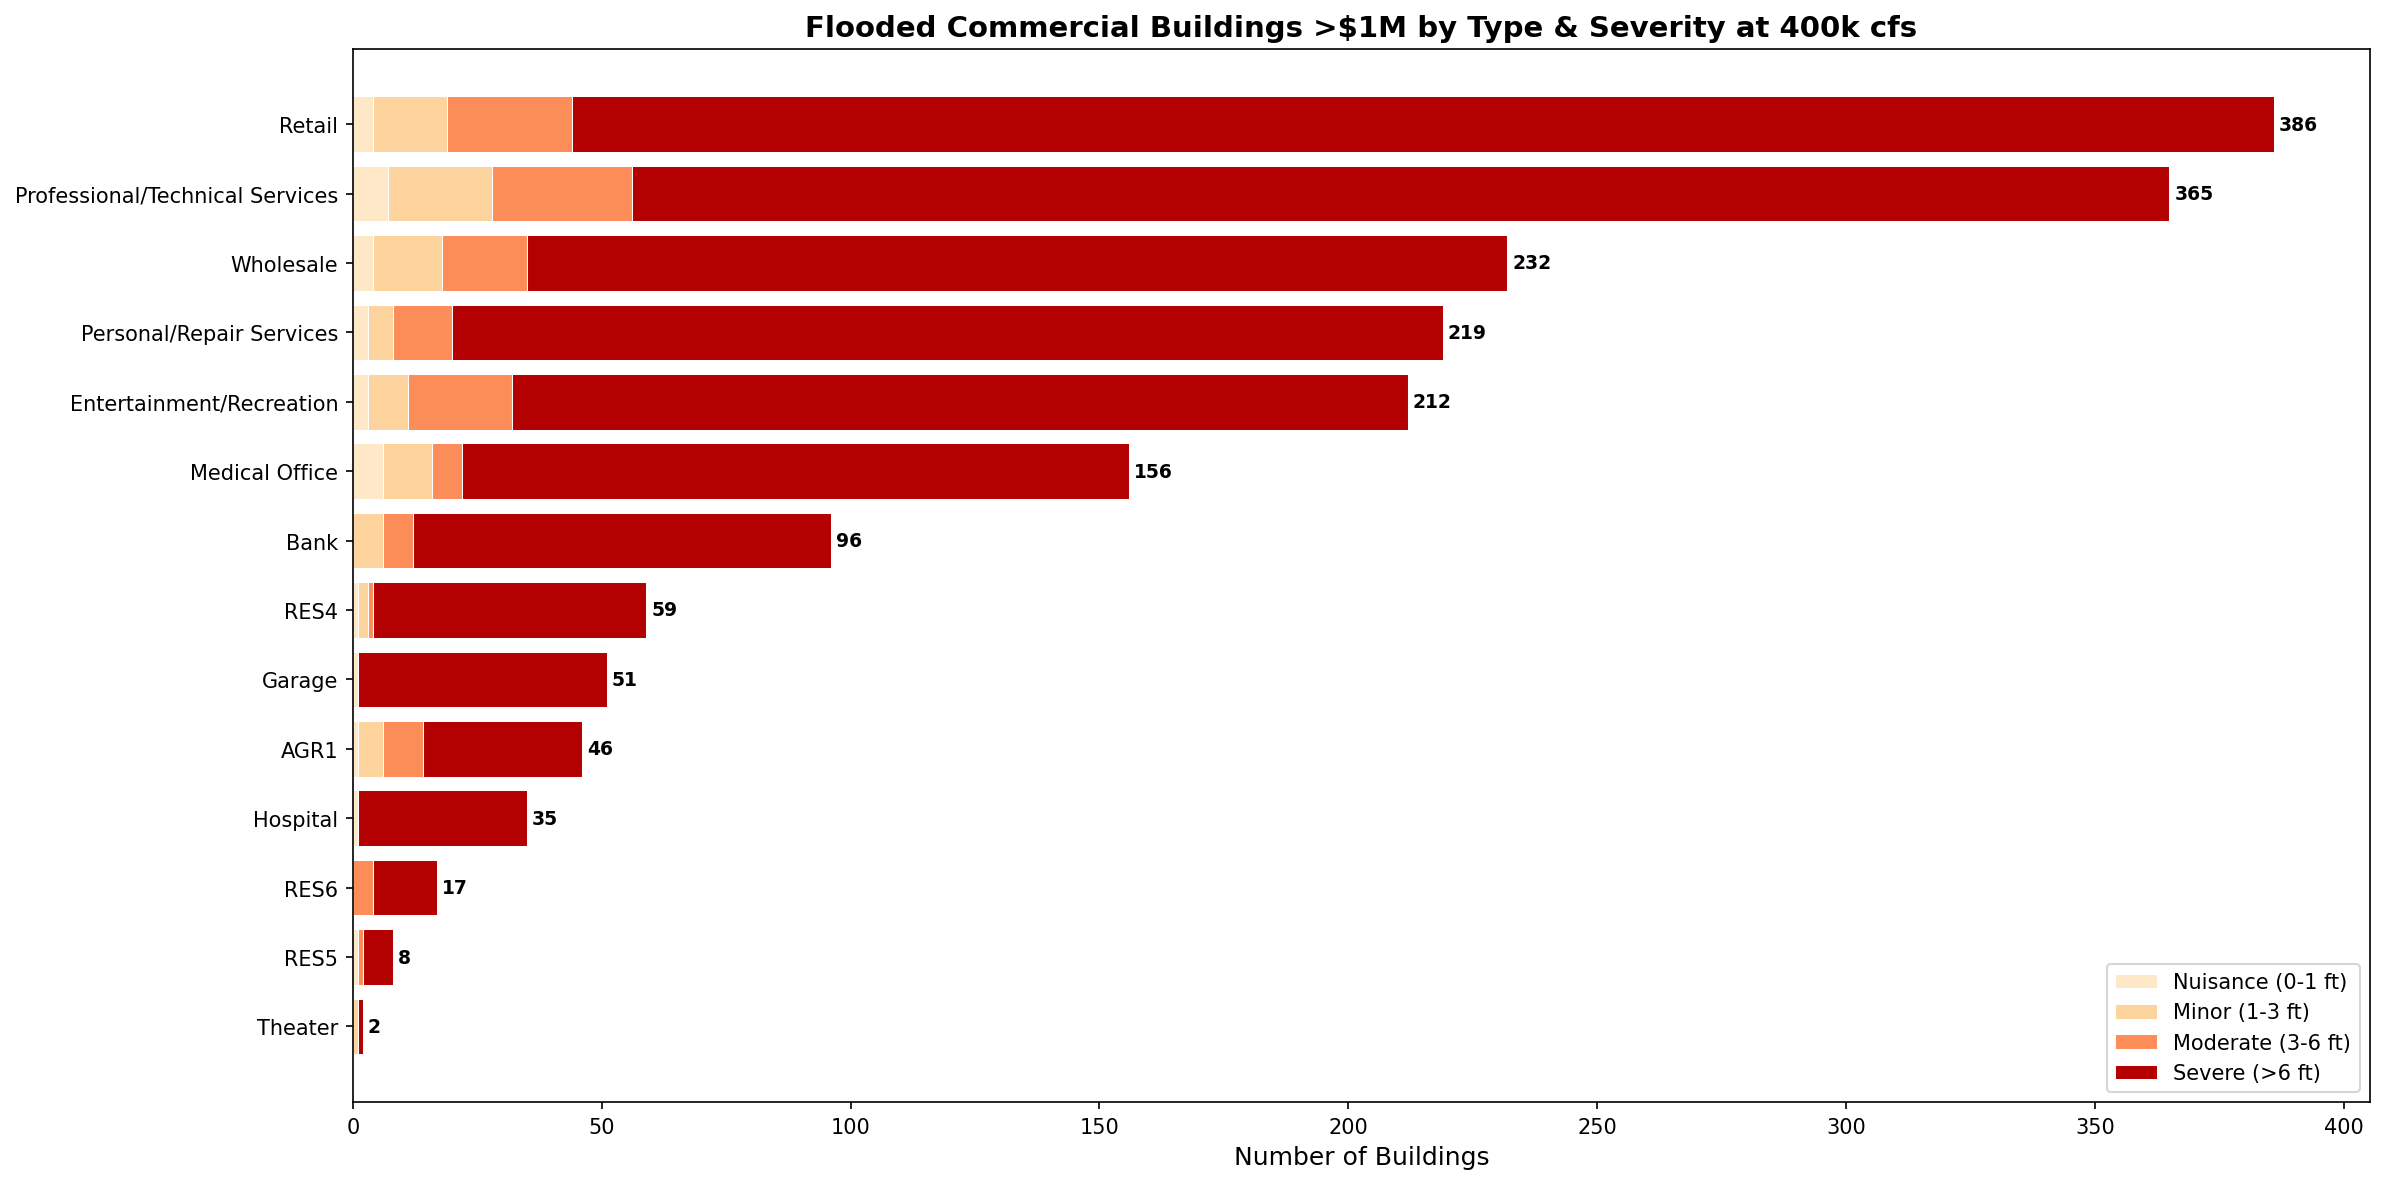

All tasks are complete. The map shows 1,884 flooded high-value commercial buildings color-coded by flood severity alongside the flood depth WMS layer. The dashboard charts break down the data by building type, value at risk, severity distribution, and the relationship between depth and structure value for the top 20 most expensive buildings.

In [ ]:
%%ask
Find all flooded commercial buildings along the Kanawha River with structure value
over $1 million at 400,000 cfs. Please generate visualizations of the result